# MNIST test

This is my attempt to use FastAI libraries to setup and enter my own models for MNIST and train them on my computer. Then to enter them

## Loading the relevant libraries

In [41]:
from fastai.vision.all import *
import torch 
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

In [2]:
# install fastkaggle if not available
try: import fastkaggle
except ModuleNotFoundError:
    !pip install -Uq fastkaggle

from fastkaggle import *

In [11]:
try: import timm
except ModuleNotFoundError:
    !pip install -Uq timm
from timm import *

In [12]:
# kaggle.json needed to be copied into .kaggle into the home folder before this
! chmod 600 /home/carljvh/.kaggle/kaggle.json

## Loading the dataset

In [8]:
# using fastai's fastkaggle library download the data from 

comp = "digit-recognizer"
path = setup_comp(comp, install='fastai "timm>=0.6.2.dev0"')

### Loading into pandas dataframes

In [39]:
# Now we use pandas to load our csv's into pandas dataframes
train = pd.read_csv(path/"train.csv", dtype=np.float32)
test  = pd.read_csv(path/'test.csv', dtype=np.float32)
sample_sub = pd.read_csv(path/"sample_submission.csv")
train.head

<bound method NDFrame.head of        label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0        1.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
1        0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2        1.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3        4.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
4        0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
...      ...     ...     ...     ...     ...     ...     ...     ...     ...   
41995    0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
41996    1.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
41997    7.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
41998    6.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
41999    9.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

       pi

In [54]:
#takes "label" collumn in our  pd dataset as the targets
y_np = train.label.values
y_np

array([1., 0., 1., ..., 7., 6., 9.], dtype=float32)

In [55]:
x_np = train.loc[:,train.columns != "label"].values/255
#We divide by 255 to normalise the data into values denotes darkness of shade between 0-1, rather than 0-255
lst1 = x_np[0]
lst1[100:210]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.7372549 , 1.        , 0.36862746,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.7490196 ,
       0.98039216, 0.99215686, 0.3647059 , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [70]:
# Splitting the data into training and testing datasets, suspect that the Pytorch dataloaders doest this, but the tutorial I used, doesn't do this for us
# (https://www.kaggle.com/code/abhinand05/mnist-introduction-to-computervision-with-pytorch)
# Note that the train_test_split function in from scikitlearn

y_train_np, y_valid_np, x_train_np, x_valid_np = train_test_split(y_np, x_np, test_size=0.2, random_state=42)

In [74]:
#There has to be a better way to do this
y_train = torch.tensor(y_train_np)
y_valid = torch.tensor(y_valid_np)
x_train = torch.tensor(x_train_np)
x_valid = torch.tensor(x_valid_np)


In [75]:
x_train, x_valid

(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]))

In [76]:
y_train, y_valid

(tensor([6., 5., 3.,  ..., 2., 6., 0.]),
 tensor([8., 1., 9.,  ..., 3., 0., 9.]))

### Preprocessing

In [77]:
# Making Datasets as per fastai 22p2 lesson 4
class Dataset():
    def __init__(self, x, y): self.x, self.y = x, y
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y[i]

In [78]:
train_ds,valid_ds = Dataset(x_train, y_train), Dataset(x_valid, y_valid)
assert len(train_ds)==len(x_train)
assert len(valid_ds)==len(x_valid)

In [83]:
train_ds.x[0], train_ds.y

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.2471, 0.9922, 0.4745, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.2471, 0.9961, 0.7922,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

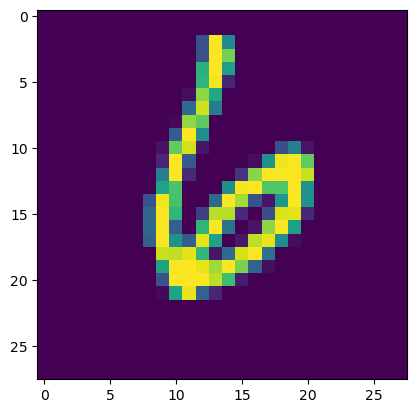

In [88]:
plt.imshow(train_ds.x[0].reshape(28,28))

# plt.imshow(xb[0].view(28,28))
